# Analisis del tiempo de juego a jugadores de la plataforma steam

## Imports iniciales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

## Primeros Insights y comportamiento del set de datos

### Exploracion simple de los conjuntos de datos con medidas de tendencia central

In [2]:
df_playtime = pd.read_csv('data/reviews.csv', usecols=['appid', 'author_playtime_forever'])

print(f"Reviews cargadas: {len(df_playtime):,}")
print(f"Nulos: {df_playtime['author_playtime_forever'].isna().sum():,}")

df_playtime = df_playtime.dropna()

# Convertir minutos a horas
df_playtime['playtime_hours'] = df_playtime['author_playtime_forever'] / 60

# Calcular promedio por juego
playtime_avg = df_playtime.groupby('appid')['playtime_hours'].agg(
    playtime_mean='mean',
    playtime_median='median',
    n_reviews='count'
).reset_index()

print(f"\nJuegos con datos de playtime: {len(playtime_avg):,}")
print(playtime_avg.describe())

Reviews cargadas: 1,048,148
Nulos: 3

Juegos con datos de playtime: 117,311
              appid  playtime_mean  playtime_median      n_reviews
count  1.173110e+05  117311.000000    117311.000000  117311.000000
mean   1.647463e+06      14.276867         9.063218       8.934755
std    9.859693e+05     133.717395       112.928272      18.043468
min    4.000000e+02       0.000000         0.000000       1.000000
25%    8.082550e+05       0.000000         0.000000       1.000000
50%    1.517202e+06       1.522807         1.100000       2.000000
75%    2.399175e+06       6.401732         4.600000       7.000000
max    3.977550e+06   21297.116667     21297.116667     100.000000


### Distribucion de tiempo de juego entre los juegos de steam

Juegos filtrados: 32,147


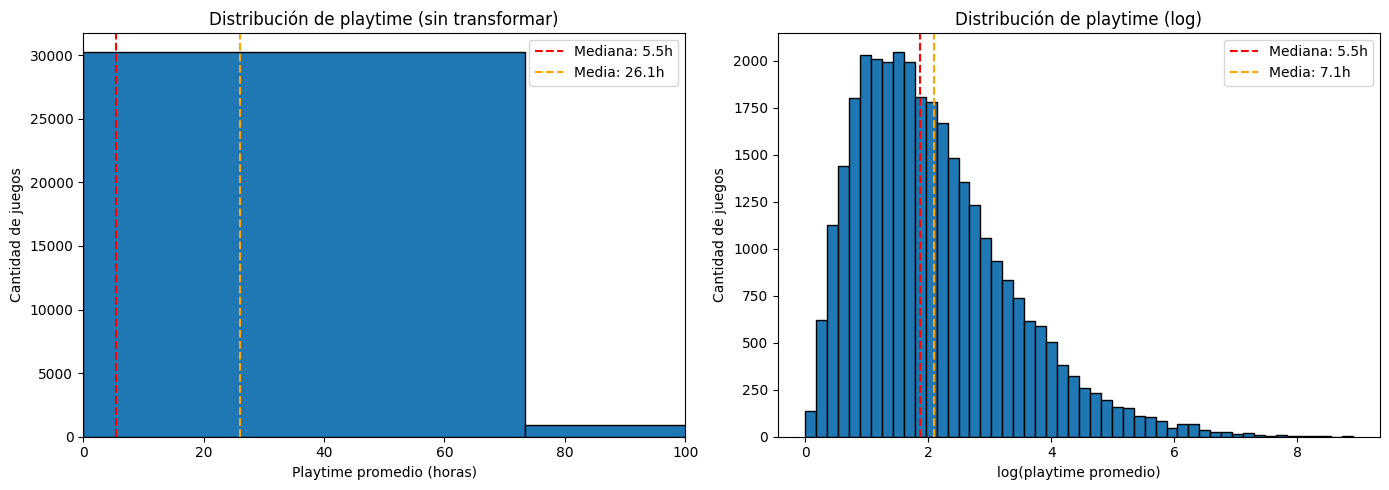

count    32147.000000
mean        26.053136
std        126.703676
min          0.000167
25%          2.136971
50%          5.463333
75%         15.171528
max       7340.052941
Name: playtime_mean, dtype: float64


In [3]:
# Filtrar juegos con al menos 5 reviews (promedio más confiable)
# Filtrar juegos con >= 5 reviews Y playtime > 0
playtime_filtrado = playtime_avg[
    (playtime_avg['n_reviews'] >= 5) & 
    (playtime_avg['playtime_mean'] > 0)
].copy()
print(f"Juegos filtrados: {len(playtime_filtrado):,}")

# Calcular estadísticas
media = playtime_filtrado['playtime_mean'].mean()
mediana = playtime_filtrado['playtime_mean'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin transformar
axes[0].hist(playtime_filtrado['playtime_mean'], bins=100, edgecolor='black')
axes[0].axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana:.1f}h')
axes[0].axvline(media, color='orange', linestyle='--', label=f'Media: {media:.1f}h')
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Playtime promedio (horas)')
axes[0].set_ylabel('Cantidad de juegos')
axes[0].set_title('Distribución de playtime (sin transformar)')
axes[0].legend()

# Con log
# Con log
log_media = np.log1p(playtime_filtrado['playtime_mean']).mean()
log_mediana = np.log1p(playtime_filtrado['playtime_mean']).median()

# Invertir para mostrar en horas reales
media_real = np.expm1(log_media)
mediana_real = np.expm1(log_mediana)

axes[1].hist(np.log1p(playtime_filtrado['playtime_mean']), bins=50, edgecolor='black')
axes[1].axvline(log_mediana, color='red', linestyle='--', label=f'Mediana: {mediana_real:.1f}h')
axes[1].axvline(log_media, color='orange', linestyle='--', label=f'Media: {media_real:.1f}h')
axes[1].set_xlabel('log(playtime promedio)')
axes[1].set_ylabel('Cantidad de juegos')
axes[1].set_title('Distribución de playtime (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(playtime_filtrado['playtime_mean'].describe())

## Eleccion de features para la prediccion del tiempo de juego

In [4]:
# Cargar datos
df_apps = pd.read_csv('data-cleaned/applications.csv', low_memory=False)
df_application_genres = pd.read_csv('data/application_genres.csv')
df_application_platforms = pd.read_csv('data/application_platforms.csv')
df_genres = pd.read_csv('data-cleaned/genres_clean.csv')

# Merge playtime con applications
df_model = playtime_filtrado.merge(df_apps, on='appid', how='inner')
print(f"Juegos tras merge: {len(df_model):,}")

# --- Features originales ---
import re

def count_langs(x):
    if pd.isna(x): return 0
    clean = re.sub(r'<[^>]+>', '', str(x))
    clean = re.sub(r'\*', '', clean)
    return len([l for l in clean.split(',') if l.strip()])

df_model['n_languages'] = df_model['supported_languages'].apply(count_langs)
df_model['price_usd'] = df_model['mat_final_price'] / 100
df_model['release_date'] = pd.to_datetime(df_model['release_date'], errors='coerce')
df_model['release_year'] = df_model['release_date'].dt.year

n_genres = df_application_genres.groupby('appid').size().rename('n_genres')
n_platforms = df_application_platforms.groupby('appid').size().rename('n_platforms')
df_model = df_model.merge(n_genres, on='appid', how='left')
df_model = df_model.merge(n_platforms, on='appid', how='left')

# Target
df_model['log_playtime'] = np.log1p(df_model['playtime_mean'])

# Filtrar outliers de precio
df_model = df_model[df_model['price_usd'] <= 60].copy()

# --- Ronda 1: Features de applications ---
df_model['mat_discount_percent'] = df_model['mat_discount_percent'].fillna(0)
df_model['has_discount'] = (df_model['mat_discount_percent'] > 0).astype(int)
df_model['log_recs'] = np.log1p(df_model['recommendations_total'].fillna(0))

# --- Ronda 2: Features de reviews ---
review_stats = pd.read_csv('data/reviews.csv', 
    usecols=['appid', 'voted_up', 'steam_purchase', 'author_num_games_owned', 'votes_up'])

review_agg = review_stats.groupby('appid').agg(
    pct_positive=('voted_up', 'mean'),
    pct_steam_purchase=('steam_purchase', 'mean'),
    avg_games_owned=('author_num_games_owned', 'mean'),
    avg_votes_up=('votes_up', 'mean')
).reset_index()

df_model = df_model.merge(review_agg, on='appid', how='left')

# --- Ronda 3: Géneros one-hot (top 10) ---
app_gen = df_application_genres.merge(df_genres, left_on='genre_id', right_on='id')
app_gen = app_gen.rename(columns={'name': 'genre_name'})

top10 = app_gen['genre_name'].value_counts().head(10).index.tolist()
print("Top 10 géneros:", top10)

for genre in top10:
    col_name = f'genre_{genre.lower().replace(" ", "_")}'
    apps_with_genre = app_gen[app_gen['genre_name'] == genre]['appid'].unique()
    df_model[col_name] = df_model['appid'].isin(apps_with_genre).astype(int)

# --- Features finales ---
genre_cols = [c for c in df_model.columns if c.startswith('genre_')]

features_v2 = [
    # Originales
    'price_usd', 'mat_achievement_count', 'n_genres', 
    'n_platforms', 'n_languages', 'release_year',
    # Nuevas de applications
    'mat_discount_percent', 'has_discount', 'log_recs',
    # Nuevas de reviews
    'pct_positive', 'pct_steam_purchase', 'avg_games_owned', 'avg_votes_up',
] + genre_cols

print(f"\nTotal features: {len(features_v2)}")

modelo_df = df_model[features_v2 + ['log_playtime']].dropna()
print(f"Filas para modelar: {len(modelo_df):,}")
print(modelo_df.describe())

Juegos tras merge: 31,930
Top 10 géneros: ['Indie', 'Action', 'Casual', 'Adventure', 'Simulation', 'RPG', 'Strategy', 'Free To Play', 'Early Access', 'Sports']

Total features: 23
Filas para modelar: 18,930
          price_usd  mat_achievement_count      n_genres   n_platforms  \
count  18930.000000           18930.000000  18930.000000  18930.000000   
mean      10.502869              36.062018      2.852826      1.438352   
std       10.294776             154.308105      1.296133      0.733512   
min        0.490000               0.000000      1.000000      1.000000   
25%        2.990000              11.000000      2.000000      1.000000   
50%        6.990000              21.000000      3.000000      1.000000   
75%       14.990000              38.000000      4.000000      2.000000   
max       60.000000            5000.000000     10.000000      3.000000   

        n_languages  release_year  mat_discount_percent  has_discount  \
count  18930.000000  18930.000000          18930.0000

## Entrenamiento de 4 modelos distintos

### Separacion de train y test

In [5]:
features = features_v2
X = modelo_df[features]
y = modelo_df['log_playtime']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (13251, 23)
X_test:  (5679, 23)


### Entrenamiento del modelo LinearRegression

In [6]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print("=== Regresión Lineal ===")
print(f"R² test: {r2_score(y_test, y_pred_lr):.4f}")
print(f"\nCoeficientes:")
coefs = pd.DataFrame({'Feature': features, 'Coeficiente': modelo_lr.coef_})
print(coefs)
print(f"Intercepto: {modelo_lr.intercept_:.4f}")

=== Regresión Lineal ===
R² test: 0.4420

Coeficientes:
                  Feature   Coeficiente
0               price_usd  3.222977e-02
1   mat_achievement_count  1.381893e-04
2                n_genres  7.978990e-02
3             n_platforms  5.457525e-02
4             n_languages -4.285227e-03
5            release_year -3.273301e-02
6    mat_discount_percent -9.955813e-04
7            has_discount  2.272900e-01
8                log_recs  1.098274e-01
9            pct_positive  4.964857e-01
10     pct_steam_purchase  3.747003e-16
11        avg_games_owned -8.269014e-05
12           avg_votes_up  7.938014e-05
13            genre_indie -1.590517e-01
14           genre_action -2.032495e-01
15           genre_casual -1.450345e-01
16        genre_adventure -2.687665e-01
17       genre_simulation  1.551704e-02
18              genre_rpg  2.701933e-01
19         genre_strategy  2.942342e-01
20     genre_free_to_play -1.866556e-02
21     genre_early_access  5.749379e-02
22           genre_sport

#### Comparacion de residuos

In [7]:
residuos = y_test.values[:10] - y_pred_lr[:10]
df_residuos = pd.DataFrame({
    'y_real': np.round(y_test.values[:10], 3),
    'y_prediccion': np.round(y_pred_lr[:10], 3),
    'residuo': np.round(residuos, 3)
})
print(df_residuos)

   y_real  y_prediccion  residuo
0   1.393         2.660   -1.266
1   1.047         1.739   -0.692
2   2.050         1.564    0.486
3   1.469         1.475   -0.007
4   2.337         2.018    0.319
5   2.478         3.074   -0.596
6   2.351         1.982    0.368
7   1.543         1.650   -0.107
8   1.830         2.367   -0.537
9   2.300         2.401   -0.102


### Entrenamiento de Modelo Polynomial Features

In [8]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Features originales: {X_train.shape[1]}")
print(f"Features polinomiales: {X_train_poly.shape[1]}")

modelo_lr_poly = LinearRegression()
modelo_lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = modelo_lr_poly.predict(X_test_poly)

Features originales: 23
Features polinomiales: 300


### Entrenamiento de modelos RandomForestRegressor

In [9]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

### Entrenamiento de modelo RandomForestRegressor con Polynomial Features

In [10]:
modelo_rf_poly = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_poly.fit(X_train_poly, y_train)
y_pred_rf_poly = modelo_rf_poly.predict(X_test_poly)

## Tabla Comparativa de los 4 modelos entrenados

In [11]:
y_pred_lr_train = modelo_lr.predict(X_train)
y_pred_lr_poly_train = modelo_lr_poly.predict(poly.transform(X_train))
y_pred_rf_train = modelo_rf.predict(X_train)
y_pred_rf_poly_train = modelo_rf_poly.predict(poly.transform(X_train))

def calcular_metricas(y_true, y_pred, y_true_train, y_pred_train):
    return {
        "R² train": r2_score(y_true_train, y_pred_train),
        "R² test": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

resumen = pd.DataFrame({
    "Reg. Lineal (Original)": calcular_metricas(y_test, y_pred_lr, y_train, y_pred_lr_train),
    "Reg. Lineal (Polinomial)": calcular_metricas(y_test, y_pred_lr_poly, y_train, y_pred_lr_poly_train),
    "Random Forest (Original)": calcular_metricas(y_test, y_pred_rf, y_train, y_pred_rf_train),
    "Random Forest (Polinomial)": calcular_metricas(y_test, y_pred_rf_poly, y_train, y_pred_rf_poly_train),
}).T

print(resumen)

                            R² train   R² test      RMSE       MAE
Reg. Lineal (Original)      0.427251  0.442028  0.863647  0.651785
Reg. Lineal (Polinomial)    0.506952  0.440295  0.864987  0.617226
Random Forest (Original)    0.928854  0.509657  0.809617  0.599284
Random Forest (Polinomial)  0.928734  0.510048  0.809295  0.599489


Se puede apreciar que el modelo Random Forest y Random Forest(Polinomial) es que tiene mejores valores de R^2 entre su entrenamiento y su testeo

## Rendimiento de los 4 modelos con la metrica R^2

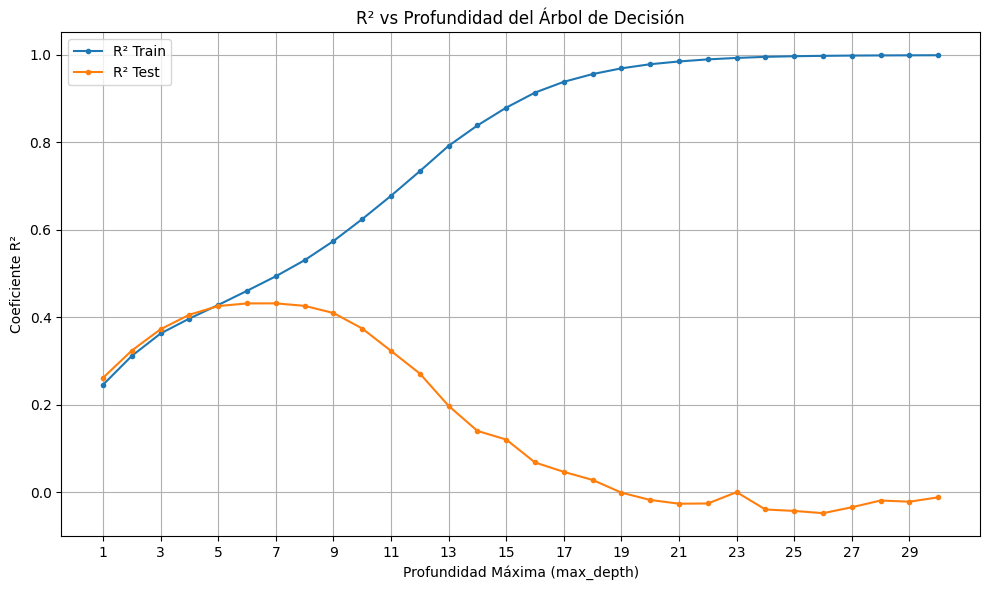

In [12]:
res = []
for md in range(1, 31):
    tree = DecisionTreeRegressor(max_depth=md, random_state=42)
    tree.fit(X_train, y_train)
    res.append({
        'profundidad': md,
        'r2_train': tree.score(X_train, y_train),
        'r2_test': tree.score(X_test, y_test)
    })

df_depth = pd.DataFrame(res)

plt.figure(figsize=(10, 6))
plt.plot(df_depth['profundidad'], df_depth['r2_train'], label='R² Train', marker='o', markersize=3)
plt.plot(df_depth['profundidad'], df_depth['r2_test'], label='R² Test', marker='o', markersize=3)
plt.title('R² vs Profundidad del Árbol de Decisión')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Coeficiente R²')
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Al final la profundidad del arbol debe ser entre 5 y 7, ya que estos valores estan por debajo del R^2 de Train pero tampoco empiezan a empeorar su rendimiento R^2

## Resultados

### Influencia de las features en la prediccion del modelo

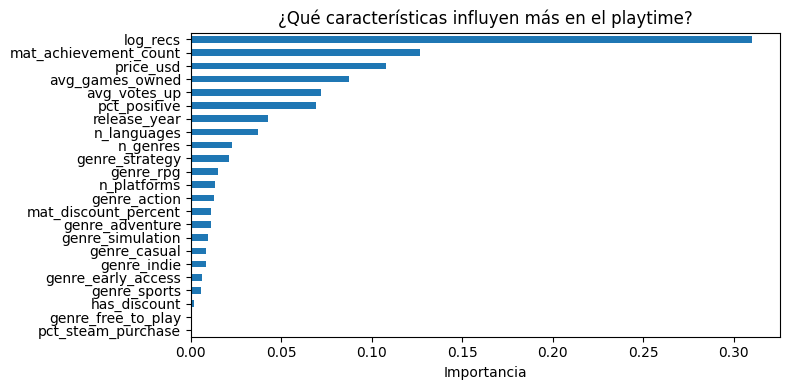

In [13]:
importancia = pd.Series(modelo_rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 4))
importancia.plot.barh()
plt.xlabel('Importancia')
plt.title('¿Qué características influyen más en el playtime?')
plt.tight_layout()
plt.show()

Se puede apreciar que la cantidad de recomendaciones (31%), la cantidad de logros (12.7%) 
y el precio del juego (10.8%) son las características que más influyen en el tiempo 
invertido en el juego. Luego le siguen la cantidad de juegos que tiene el usuario (8.7%), 
la cantidad de votos positivos (7.2%) y el porcentaje de reviews positivas (6.9%). 

También es notable que la cantidad de idiomas, géneros y plataformas son factores a 
considerar, aunque con menor peso. El eje de "Importancia" indica qué proporción del 
poder predictivo del modelo aporta cada variable, se calcula midiendo cuánto reduce 
cada feature el error en los árboles del Random Forest, y los valores suman 1.0 (100%).

## Grafico de dispercion Random Forest

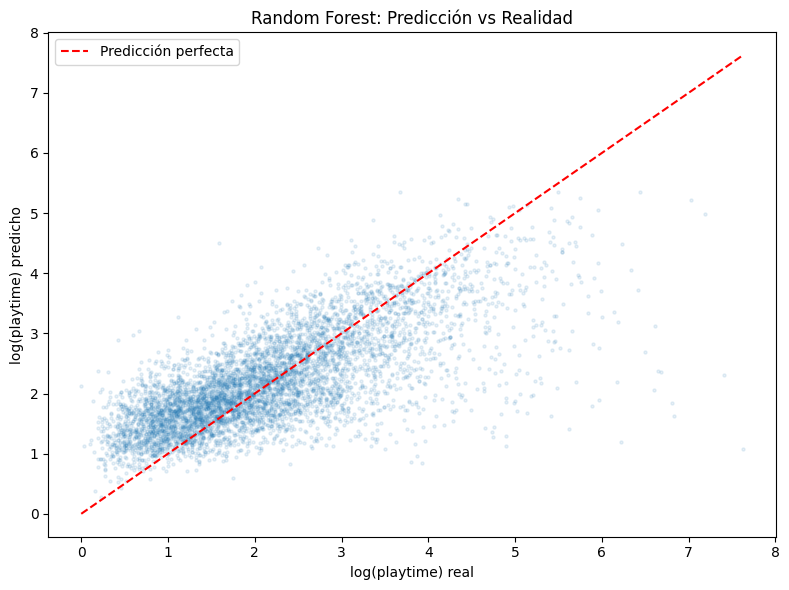

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.1, s=5)
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.xlabel('log(playtime) real')
plt.ylabel('log(playtime) predicho')
plt.title('Random Forest: Predicción vs Realidad')
plt.legend()
plt.tight_layout()
plt.show()

Comparando el tiempo de juego real con el tiempo de juego predicho, se puede observar una ligera tendencia a la prediccion perfecta en el grafico. Se puede apreciar que para valores altos el modelo no puede predecir correctamente. Sin embargo, para los valores bajos, puede predecirlo medianamente bien, con un desplazamiento a una prediccion mayor a la esperada.